In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb

from sklearn.metrics import (
    mean_squared_error, r2_score, roc_auc_score, roc_curve,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

In [4]:
# Load Data
data = np.load('processed_wdbc.npz')
X_full = data['X']
y_full = data['y']

print("✅ Data Loaded Successfully")
print("Shape of X:", X_full.shape)
print("Shape of y:", y_full.shape)

✅ Data Loaded Successfully
Shape of X: (569, 30)
Shape of y: (569,)


In [6]:
feature_names = [
    'Mean Radius', 'Mean Texture', 'Mean Perimeter', 'Mean Area', 'Mean Smoothness',
    'Mean Compactness', 'Mean Concavity', 'Mean Concave Points', 'Mean Symmetry', 'Mean Fractal Dimension',
    'Radius SE', 'Texture SE', 'Perimeter SE', 'Area SE', 'Smoothness SE',
    'Compactness SE', 'Concavity SE', 'Concave Points SE', 'Symmetry SE', 'Fractal Dimension SE',
    'Worst Radius', 'Worst Texture', 'Worst Perimeter', 'Worst Area', 'Worst Smoothness',
    'Worst Compactness', 'Worst Concavity', 'Worst Concave Points', 'Worst Symmetry', 'Worst Fractal Dimension'
]

# Build DataFrame
X_df = pd.DataFrame(X_full, columns=feature_names)
X_df['Diagnosis'] = y_full

In [7]:
corr_matrix = X_df.corr()
top_features = corr_matrix['Diagnosis'].abs().sort_values(ascending=False).index[1:6]  # Top 5 correlated features
print("\nTop 5 Correlated Features Selected:", list(top_features))

selected_features = X_df[top_features].values


Top 5 Correlated Features Selected: ['Worst Concave Points', 'Worst Perimeter', 'Mean Concave Points', 'Worst Radius', 'Mean Perimeter']


In [8]:
# 4. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    selected_features, y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

print("\nTrain set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)


Train set: (455, 5) (455,)
Test set: (114, 5) (114,)


In [14]:
# Risk Scoring Models
models = {
    "Linear Regression": LinearRegression(),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42),
    "XGBoost Regressor": XGBRegressor(random_state=42),
    "Support Vector Regressor (SVR)": SVR(),
    "K-Nearest Neighbors Regressor (KNN)": KNeighborsRegressor(),
    "CatBoost Regressor": CatBoostRegressor(verbose=0, random_state=42),
    "LightGBM Regressor": lgb.LGBMRegressor(random_state=42)
}

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000085 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 756
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 5
[LightGBM] [Info] Start training from score 0.373626
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

c:\Users\Aayush Pradhan\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


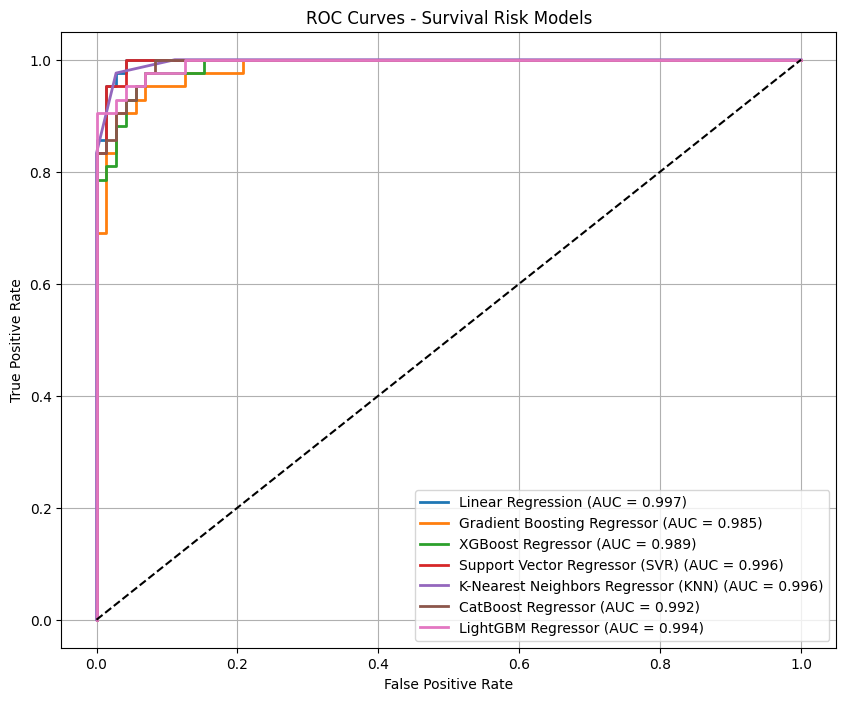

In [15]:
# Train Models and Evaluate
risk_results = {}
plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)

    risk_results[name] = {
        "MSE": mse,
        "R² Score": r2,
        "ROC-AUC (Risk Prediction)": auc
    }
    
    fpr, tpr, _ = roc_curve(y_test, y_pred)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Survival Risk Models')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
risk_results_df = pd.DataFrame(risk_results).T.sort_values(by='ROC-AUC (Risk Prediction)', ascending=False)
print("\n📋 Risk Scoring Model Leaderboard:")
display(risk_results_df)


📋 Risk Scoring Model Leaderboard:


,MSE,R² Score,ROC-AUC (Risk Prediction)
Linear Regression,0.067004,0.712041,0.997024
Support Vector Regressor (SVR),0.036456,0.843324,0.996362
K-Nearest Neighbors Regressor (KNN),0.027368,0.882381,0.996362
LightGBM Regressor,0.035571,0.847130,0.993717
CatBoost Regressor,0.036888,0.841470,0.992394
XGBoost Regressor,0.046587,0.799785,0.989087
Gradient Boosting Regressor,0.048302,0.792415,0.985119


In [17]:
# Best Model Risk Scores Full Prediction
best_model_name = risk_results_df.index[0]
best_model = models[best_model_name]

y_pred_full = best_model.predict(selected_features)

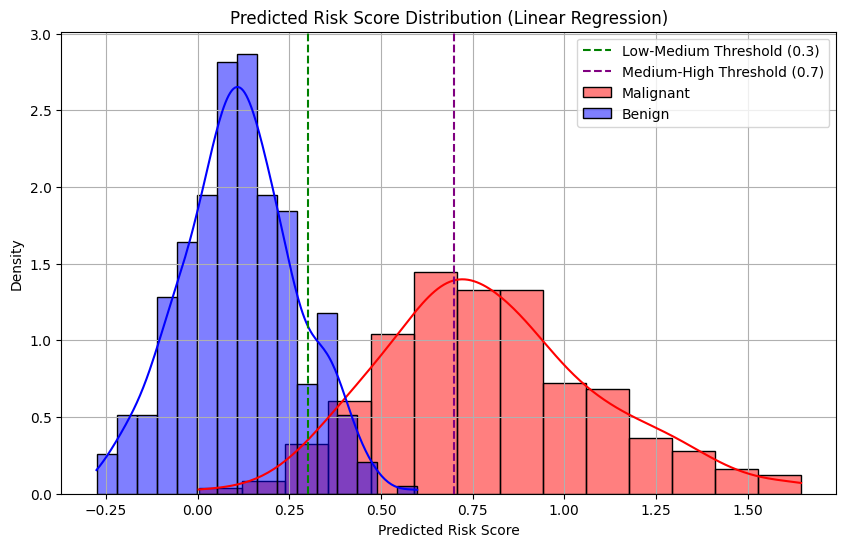


🧮 Risk Group Counts:
Counter({'Low Risk': 314, 'Medium Risk': 130, 'High Risk': 125})


In [24]:
# Risk Stratification
# Define thresholds
low_threshold = 0.3
high_threshold = 0.7

def stratify_risk(score):
    if score < low_threshold:
        return 'Low Risk'
    elif score < high_threshold:
        return 'Medium Risk'
    else:
        return 'High Risk'

risk_buckets = np.array([stratify_risk(score) for score in y_pred_full])

# Risk Distribution Plot
plt.figure(figsize=(10,6))
sns.histplot(y_pred_full[y_full==1], color='red', label='Malignant', kde=True, stat='density')
sns.histplot(y_pred_full[y_full==0], color='blue', label='Benign', kde=True, stat='density')
plt.axvline(low_threshold, color='green', linestyle='--', label='Low-Medium Threshold (0.3)')
plt.axvline(high_threshold, color='purple', linestyle='--', label='Medium-High Threshold (0.7)')
plt.title(f'Predicted Risk Score Distribution ({best_model_name})')
plt.xlabel('Predicted Risk Score')
plt.ylabel('Density')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Show stratified counts
import collections
print("\n🧮 Risk Group Counts:")
print(collections.Counter(risk_buckets))

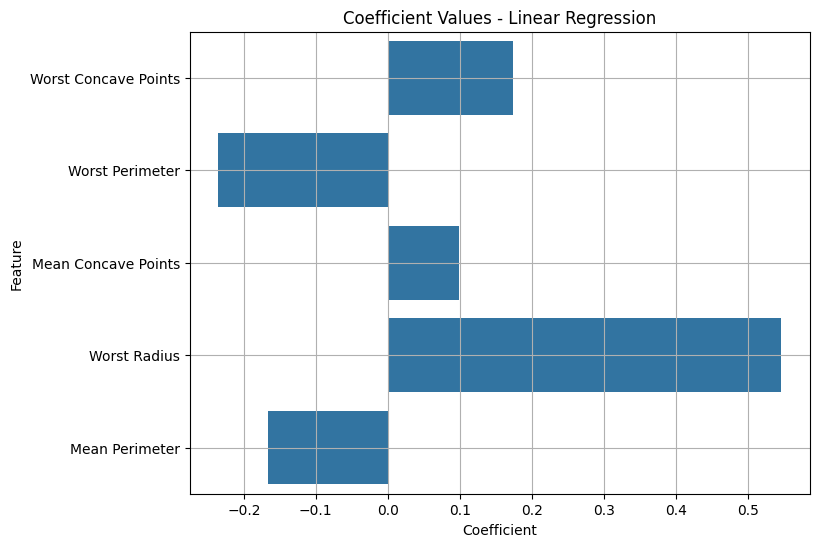

In [21]:
# Feature Importance from Best Model (if tree-based)
if hasattr(best_model, 'feature_importances_'):
    plt.figure(figsize=(8,6))
    sns.barplot(x=best_model.feature_importances_, y=[f for f in top_features])
    plt.title(f'Feature Importance - {best_model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.grid(True)
    plt.show()

elif hasattr(best_model, 'coef_'):
    plt.figure(figsize=(8,6))
    sns.barplot(x=best_model.coef_.flatten(), y=[f for f in top_features])
    plt.title(f'Coefficient Values - {best_model_name}')
    plt.xlabel('Coefficient')
    plt.ylabel('Feature')
    plt.grid(True)
    plt.show()

else:
    print(f"No feature importance or coefficients available for {best_model_name}")

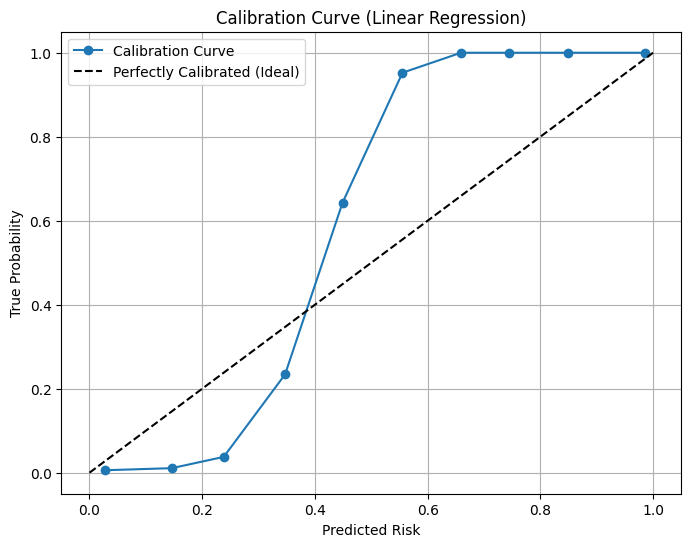

In [25]:
# Calibration Curve
y_pred_full_clipped = np.clip(y_pred_full, 0, 1)

prob_true, prob_pred = calibration_curve(y_full, y_pred_full_clipped, n_bins=10)

plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration Curve')
plt.plot([0,1],[0,1],'k--', label='Perfectly Calibrated (Ideal)')
plt.title(f'Calibration Curve ({best_model_name})')
plt.xlabel('Predicted Risk')
plt.ylabel('True Probability')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()